In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re
import string
from collections import Counter
from itertools import combinations

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import gensim
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

import networkx as nx

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /Users/junyup/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/junyup/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/junyup/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Load data
df = pd.read_csv('difraud_data.csv')

# Overview
print(df.shape)
df.head()

(56597, 4)


,category,split,text,label
0,fake_news,train,posted by Eddie Gun man have stolen a Dirty Bo...,1
1,fake_news,train,President Donald Trump's 2018 budget asks Cong...,0
2,fake_news,train,The International Committee of the Red Cross (...,0
3,fake_news,train,Australia will not be allowed to walk away fro...,0
4,fake_news,train,The Uzbek man arrested in the terrorism rampag...,0


In [4]:
# Structure & dtypes
df.info()
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 56597 entries, 0 to 56596
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  56597 non-null  str  
 1   split     56597 non-null  str  
 2   text      56597 non-null  str  
 3   label     56597 non-null  int64
dtypes: int64(1), str(3)
memory usage: 1.7 MB


category      str
split         str
text          str
label       int64
dtype: object

In [5]:
# Column names
df.columns.tolist()

['category', 'split', 'text', 'label']

In [6]:
# Categorical column value counts
print(df['category'].value_counts())
print()
print(df['split'].value_counts())
print()
print(df['label'].value_counts())

category
fake_news    20456
phishing     15272
job_scams    14295
sms           6574
Name: count, dtype: int64

split
train         45276
test           5662
validation     5659
Name: count, dtype: int64

label
0    39818
1    16779
Name: count, dtype: int64


In [7]:
# Missing values
print(df.isnull().sum())
print()
print(df.isnull().mean() * 100)

category    0
split       0
text        0
label       0
dtype: int64

category    0.0
split       0.0
text        0.0
label       0.0
dtype: float64


In [8]:
# Duplicate rows
df.duplicated().sum()
df.duplicated(subset='text').sum()

np.int64(113)

In [9]:
# Sample records per label/category
df.sample(5, random_state=42)

,category,split,text,label
26359,job_scams,train,Lost My Name combines the power of storytellin...,0
39324,phishing,train,Update your account It has come to our attenti...,1
39448,phishing,train,Hi Stepan and Eugene ( Eugene are you getting ...,0
46205,phishing,train,Delete greg…paula Marianne matt Sarajane daryl...,0
21460,job_scams,train,Mission The Bayview Hunters Point Health and E...,0


In [10]:
# Target distribution
target_col = 'label'

counts = df[target_col].value_counts().sort_index()
ratios = df[target_col].value_counts(normalize=True).sort_index() * 100

# Table view
summary = pd.DataFrame({'Count': counts, 'Ratio (%)': ratios.round(2)})
print(summary)

       Count  Ratio (%)
label                  
0      39818      70.35
1      16779      29.65


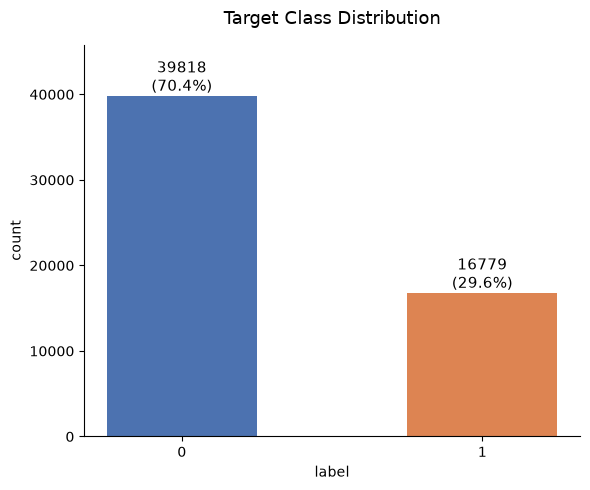

In [11]:
# Bar chart with count + percentage labels
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    counts.index.astype(str),
    counts.values,
    color=['#4C72B0', '#DD8452'],
    width=0.5
)

# annotate each bar with count and percentage
for bar, count, ratio in zip(bars, counts.values, ratios.values):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{count}\n({ratio:.1f}%)',
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('Target Class Distribution', fontsize=13, pad=15)
ax.set_xlabel('label')
ax.set_ylabel('count')
ax.set_ylim(0, max(counts.values) * 1.15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# Compute character counts & word counts
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

df[['char_count', 'word_count']].describe()

,char_count,word_count
count,56597.000000,56597.000000
mean,2147.333887,347.761047
std,5659.236462,614.832578
min,2.000000,1.000000
25%,516.000000,81.000000
50%,1253.000000,196.000000
75%,2529.000000,409.000000
max,999999.000000,45461.000000


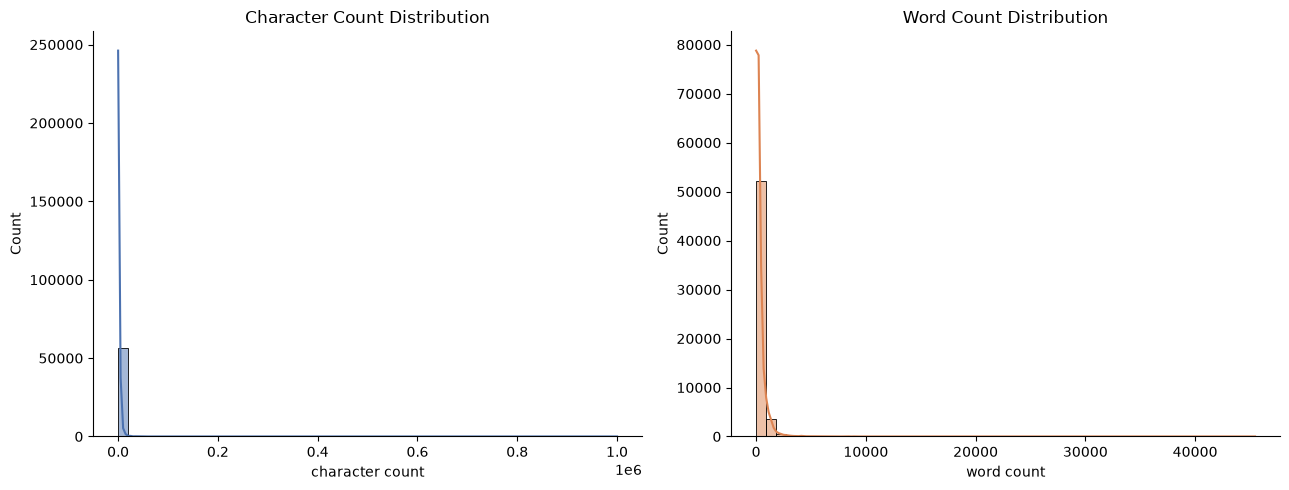

In [13]:
# Distribution plots: char_count & word_count
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['char_count'], bins=50, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Character Count Distribution')
axes[0].set_xlabel('character count')
axes[0].spines[['top', 'right']].set_visible(False)

sns.histplot(df['word_count'], bins=50, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('word count')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

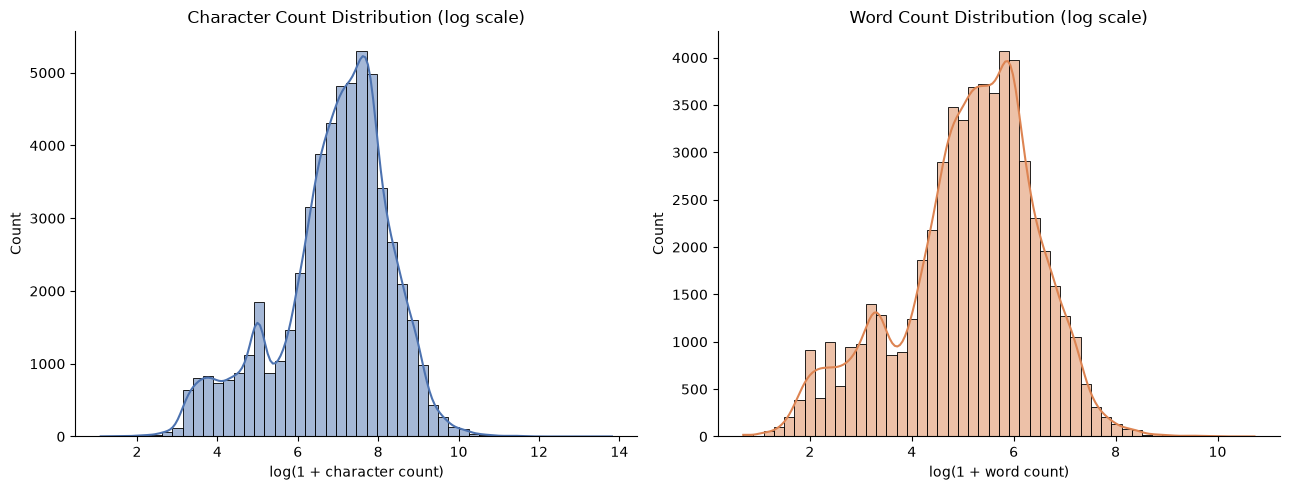

In [14]:
# Check skew: long-tail texts may need log scale
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(np.log1p(df['char_count']), bins=50, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Character Count Distribution (log scale)')
axes[0].set_xlabel('log(1 + character count)')
axes[0].spines[['top', 'right']].set_visible(False)

sns.histplot(np.log1p(df['word_count']), bins=50, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Word Count Distribution (log scale)')
axes[1].set_xlabel('log(1 + word count)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

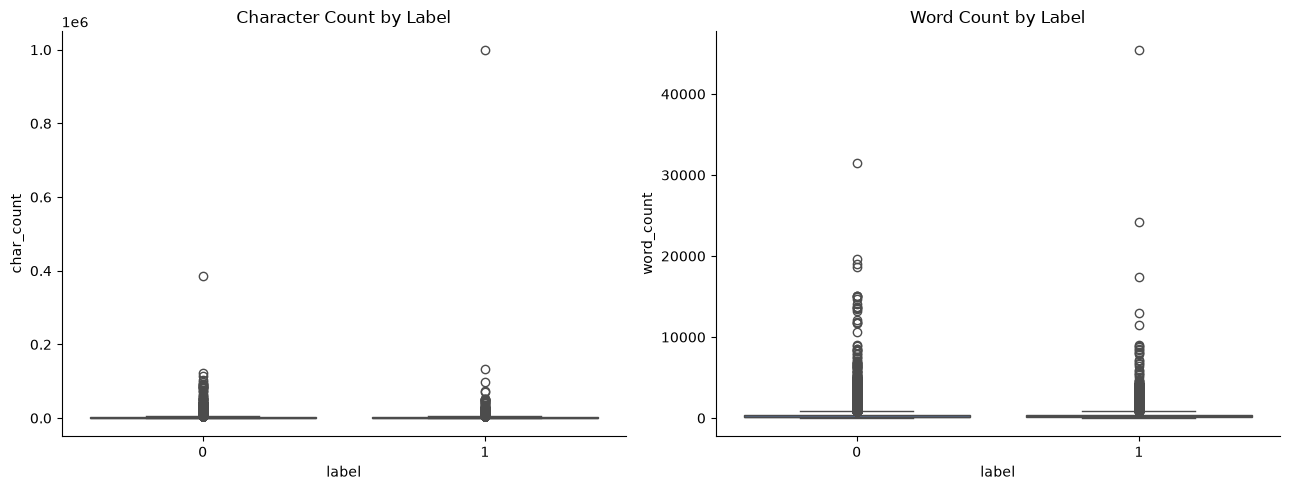

In [15]:
# Compare distributions by label (fraud vs. non-fraud)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='label', y='char_count', ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Character Count by Label')
axes[0].spines[['top', 'right']].set_visible(False)

sns.boxplot(data=df, x='label', y='word_count', ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Word Count by Label')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [16]:
# Summary stats table by category
df.groupby('category')[['char_count', 'word_count']].agg(['mean', 'median', 'std', 'min', 'max'])

char_count                                   word_count         \
                  mean  median          std min     max        mean median   
category                                                                     
fake_news  3356.135119  2484.0  3671.940666  48  134206  558.703412  408.0   
job_scams  1245.009444  1056.0   873.246402  44   14810  186.983841  160.0   
phishing   2260.787389  1007.0  9765.023192   6  999999  358.454623  160.0   
sms          84.484484    68.0    59.043448   2     910   16.145726   14.0   

                                  
                  std min    max  
category                          
fake_news  624.195297   7  24234  
job_scams  129.924602   6   2115  
phishing   855.562746   1  45461  
sms         11.062898   1    171

In [17]:
# Define outlier using IQR method
def get_outlier_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

char_lower, char_upper = get_outlier_bounds(df['char_count'])
word_lower, word_upper = get_outlier_bounds(df['word_count'])

df['is_char_outlier'] = ~df['char_count'].between(char_lower, char_upper)
df['is_word_outlier'] = ~df['word_count'].between(word_lower, word_upper)

print(f"char_count outliers: {df['is_char_outlier'].sum()} ({df['is_char_outlier'].mean() * 100:.2f}%)")
print(f"word_count outliers: {df['is_word_outlier'].sum()} ({df['is_word_outlier'].mean() * 100:.2f}%)")
print(f"bounds - char: [{char_lower:.0f}, {char_upper:.0f}], word: [{word_lower:.0f}, {word_upper:.0f}]")

char_count outliers: 4407 (7.79%)
word_count outliers: 4533 (8.01%)
bounds - char: [-2504, 5548], word: [-411, 901]


In [18]:
# Check for suspicious sentinel/placeholder values (e.g. 999999)
df[['char_count', 'word_count']].sort_values('char_count', ascending=False).head(10)

,char_count,word_count
40153,999999,45461
44087,386902,31532
13888,134206,24234
48435,121699,19591
34765,113971,19068
44133,104576,18704
49496,98727,13655
1276,98696,17427
43373,93507,15018
43069,92973,15126


In [19]:
# Where do outlieres concentrate? category & label breakdown
outlier_by_cat = pd.crosstab(df['category'], df['is_char_outlier'], normalize='index') * 100
outlier_by_label = pd.crosstab(df['label'], df['is_char_outlier'], normalize='index') * 100

print(outlier_by_cat)
print(outlier_by_label)

is_char_outlier       False      True 
category                              
fake_news         84.938404  15.061596
job_scams         99.713186   0.286814
phishing          91.585909   8.414091
sms              100.000000   0.000000
is_char_outlier      False     True 
label                               
0                91.443568  8.556432
1                94.040169  5.959831


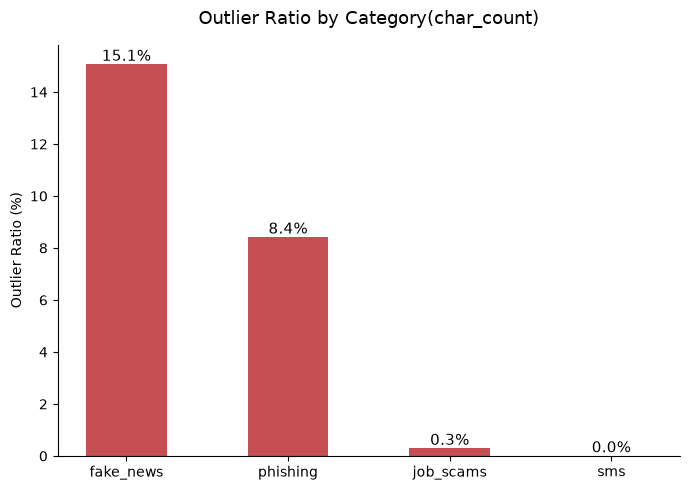

In [20]:
# Visualize outlier ratio by category
fig, ax = plt.subplots(figsize=(7, 5))

outlier_ratio = df.groupby('category')['is_char_outlier'].mean() * 100
outlier_ratio = outlier_ratio.sort_values(ascending=False)

bars = ax.bar(outlier_ratio.index, outlier_ratio.values, color='#C44E52', width=0.5)

for bar, val in zip(bars, outlier_ratio.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
    
ax.set_title('Outlier Ratio by Category(char_count)', fontsize=13, pad=15)
ax.set_ylabel('Outlier Ratio (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [21]:
# Inspect extrem outliers directly (longeest texts)
pd.set_option('display.max_colwidth', 200)
df.sort_values('char_count', ascending=False)[['category', 'label', 'char_count', 'word_count', 'text']].head(10)

,category,label,char_count,word_count,text
40153,phishing,1,999999,45461,"Security Alert Dear 053732488-0001@t-online.de, 05a@f04.navy.gov.au, 06a@f06.navy.gov.au, 072477202@t-online.de, 0853043094@telia.com, 100012.71@compuserve.com, 100101.3220@compuserve.com, 100144...."
44087,phishing,0,386902,31532,"Dear all, Please find attached the Bern2.5CC model output for the IPCC-AR4 millenium simulations, all spanning the period from 1000 - 1998AD. Some plots including a preliminary comparison between ..."
13888,fake_news,1,134206,24234,"The Hard Working American vs. The Government Parasite By Michael Snyder, on April 10th, 2012 Which lifestyle choice produces better results – being a hard working American or being a government p..."
48435,phishing,0,121699,19591,"Enron Discusses Credit Line of $1 Billion to $2 Billion With Banks The Wall Street Journal, 10/29/01 Manager's Journal: How Enron Ran Out of Gas The Wall Street Journal, 10/29/01 Enron Seeks Addit..."
34765,phishing,0,113971,19068,"2016 DAILY UPDATE - 5/19/16 ROUNDUP UPDATE DONALD TRUMP ROUNDUP HOW FASCISM COMES TO AMERICA: ""This is how fascism comes to America, not with jackboots and salutes (although there have been salute..."
44133,phishing,0,104576,18704,"2016 DAILY UPDATE - 5/5/16 DONALD TRUMP The Rolling Stones Asked Donald Trump To Stop Playing Their Songs At His Campaign Rallies. ""The Rolling Stones have asked presumptive Republican presidentia..."
49496,phishing,0,98727,13655,"trwcrn.rwm Tree-ring widths (TRW) chronology: -------------------------------------------------------------------- Ident., Trees, Inent. N (trees) No. No. -----------------------------------------..."
1276,fake_news,1,98696,17427,"55 Reasons Why California Is The Worst State In America December 12th, 2012 Why in the world would anyone want to live in the state of California at this point? The entire state is rapidly becomi..."
43373,phishing,0,93507,15018,"Enron Taps $3 Billion From Bank Lines In Pre-Emptive Move to Ensure Liquidity --- Firm Will Pay Debt, Keep Cash Cushion The Wall Street Journal, 10/26/01 Deals & Deal Makers: Enron Officials Sell ..."
43069,phishing,0,92973,15126,"Dear Martin and all others, Having read the new manuscript, I would like to draw the attention of all of you to the section about McIntyre&McKitrick vs Mann et al. I am not entirely happy with thi..."


In [22]:
# Inspect the shortest texts too (potential empty/garbage entries)
df.sort_values('char_count')[['category', 'label', 'char_count', 'word_count', 'text']].head(10)

,category,label,char_count,word_count,text
54527,sms,0,2,1,Ok
51292,sms,0,2,1,:)
52048,sms,0,3,1,Ok.
51036,sms,0,3,1,645
56491,sms,0,3,1,Yup
53417,sms,0,3,1,\ER
53684,sms,0,4,2,U 2.
55723,sms,0,4,1,Ok..
50444,sms,0,4,1,Okie
51497,sms,0,5,1,Ok...


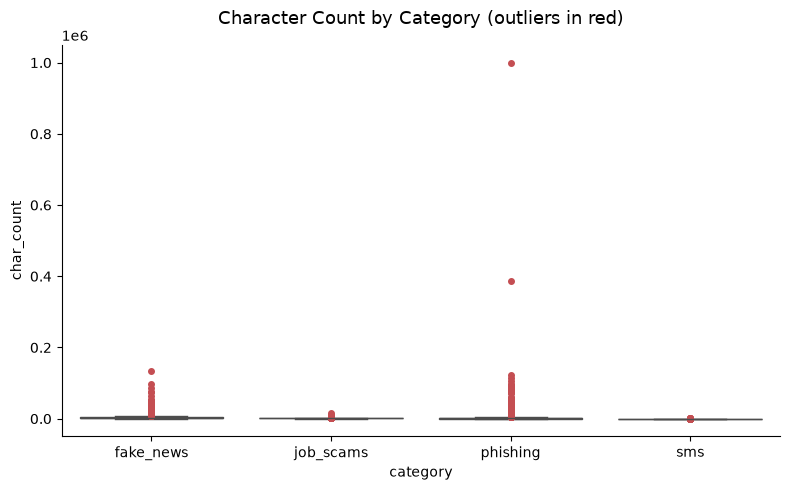

In [ ]:
# Boxplot with outliers highlighted separately
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x='category', y='char_count', ax=ax, color='#4C72B0',
            flierprops={'markerfacecolor': '#C44E52', 'markeredgecolor': '#C44E52', 'markersize': 4})

ax.set_title('Character Count by Category (outliers in red)', fontsize=13, pad=15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [24]:
# Define tokenization function
stop_words = set(stopwords.words('english'))

def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)          # remove digits/special chars
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return tokens

# Some rows have extremely long text (e.g. 999999 chars), so applying to the
# full df can be slow. Consider filtering with df[~df['is_char_outlier']] first.
df['tokens'] = df['text'].apply(tokenize)
df['token_count'] = df['tokens'].str.len()

# Overall word frequency
all_tokens = [tok for tokens in df['tokens'] for tok in tokens]
word_freq = Counter(all_tokens)

top_n = 20
top_words = word_freq.most_common(top_n)
top_words_df = pd.DataFrame(top_words, columns=['word', 'count'])
top_words_df

,word,count
0,said,82621
1,trump,79536
2,com,46709
3,would,44736
4,new,39521
5,one,39084
6,people,36880
7,president,30264
8,also,29641
9,time,28985


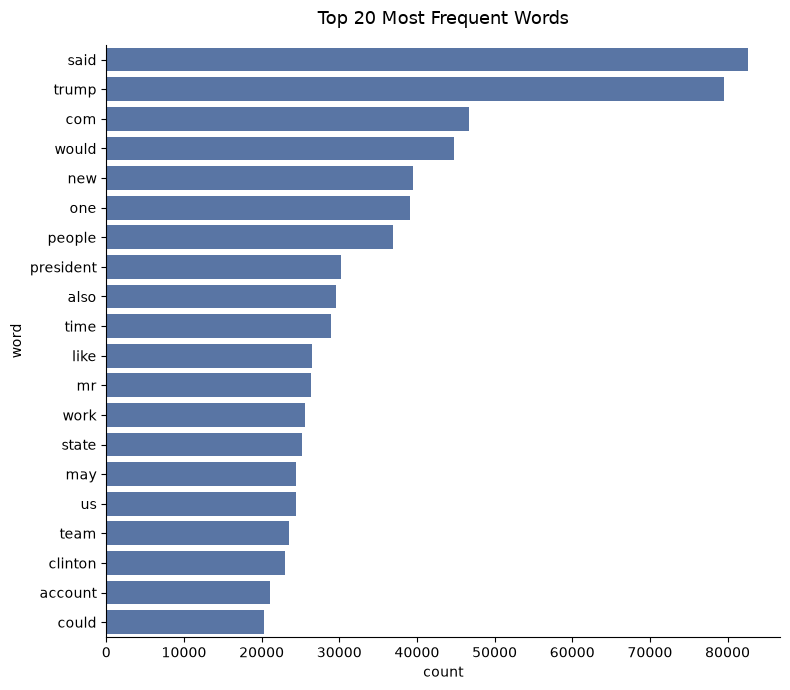

In [ ]:
# Visualize most frequent words
fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=top_words_df, x='count', y='word', color='#4C72B0', ax=ax)
ax.set_title(f'Top {top_n} Most Frequent Words', fontsize=13, pad=15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Compare word frequency by label / category
def top_words_by_group(df, group_col, group_val, n=15):
    tokens = [tok for tokens in df.loc[df[group_col] == group_val, 'tokens'] for tok in tokens]
    return Counter(tokens).most_common(n)

for label_val in sorted(df['label'].unique()):
    print(f"--- label={label_val} ---")
    print(top_words_by_group(df, 'label', label_val))
    print()

for cat in df['category'].unique():
    print(f"--- category={cat} ---")
    print(top_words_by_group(df, 'category', cat))
    print()

--- label=0 ---
[('said', 70533), ('trump', 50263), ('would', 32725), ('new', 30214), ('one', 25586), ('mr', 24789), ('people', 22926), ('work', 21657), ('also', 21486), ('team', 20852), ('president', 20649), ('time', 20356), ('state', 18312), ('may', 17078), ('like', 17069)]

--- label=1 ---
[('com', 34255), ('trump', 29273), ('account', 17654), ('people', 13954), ('one', 13498), ('said', 12088), ('would', 12011), ('us', 12010), ('clinton', 10908), ('president', 9615), ('like', 9391), ('new', 9307), ('information', 9034), ('please', 8642), ('time', 8629)]

--- category=fake_news ---
[('said', 74650), ('trump', 65093), ('would', 31417), ('people', 27139), ('president', 26662), ('one', 26200), ('mr', 23933), ('new', 20734), ('clinton', 20113), ('also', 19503), ('state', 19422), ('like', 16616), ('states', 15329), ('government', 15220), ('could', 14858)]

--- category=job_scams ---
[('team', 17170), ('work', 14241), ('experience', 9745), ('business', 9494), ('company', 8850), ('new', 856

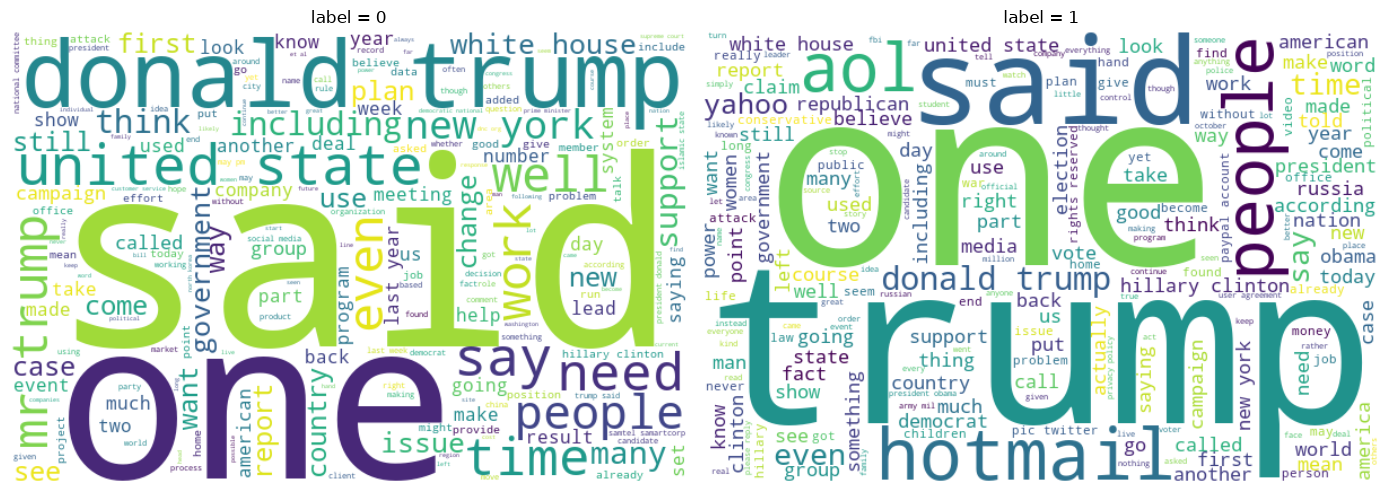

In [27]:
# Word clouds (e.g. compare label 0 vs 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, label_val in zip(axes, sorted(df['label'].unique())):
    text_blob = ' '.join(tok for tokens in df.loc[df['label'] == label_val, 'tokens'] for tok in tokens)
    wc = WordCloud(width=600, height=400, background_color='white').generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'label = {label_val}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Generate n-grams from tokenized text
def get_ngrams(tokens, n):
    return list(ngrams(tokens, n))

# Build bigrams and trigrams for every row (relies on the 'tokens' column from the previous step)
df['bigrams'] = df['tokens'].apply(lambda t: get_ngrams(t, 2))
df['trigrams'] = df['tokens'].apply(lambda t: get_ngrams(t, 3))

# Overall n-gram frequency
all_bigrams = [bg for bigrams in df['bigrams'] for bg in bigrams]
all_trigrams = [tg for trigrams in df['trigrams'] for tg in trigrams]

bigram_freq = Counter(all_bigrams)
trigram_freq = Counter(all_trigrams)

top_n = 20
top_bigrams = pd.DataFrame(
    [(' '.join(bg), cnt) for bg, cnt in bigram_freq.most_common(top_n)],
    columns=['bigram', 'count']
)
top_trigrams = pd.DataFrame(
    [(' '.join(tg), cnt) for tg, cnt in trigram_freq.most_common(top_n)],
    columns=['trigram', 'count']
)

print(top_bigrams)
print()
print(top_trigrams)

               bigram  count
0        donald trump  15748
1       united states  12161
2            new york   7892
3         white house   7842
4         hotmail com   7822
5     hillary clinton   7221
6            mr trump   7001
7             aol com   6561
8           yahoo com   4800
9           last year   3296
10          last week   3115
11         trump said   3107
12   customer service   3042
13       social media   2971
14  samtel samartcorp   2832
15      supreme court   2755
16         would like   2675
17       barack obama   2628
18    president obama   2613
19   president donald   2612

                               trigram  count
0               president donald trump   2585
1                samtel samartcorp com   2575
2        democratic national committee   2235
3                       new york times   2124
4                      pic twitter com   1666
5               president barack obama   1664
6         director democratic national    996
7                     

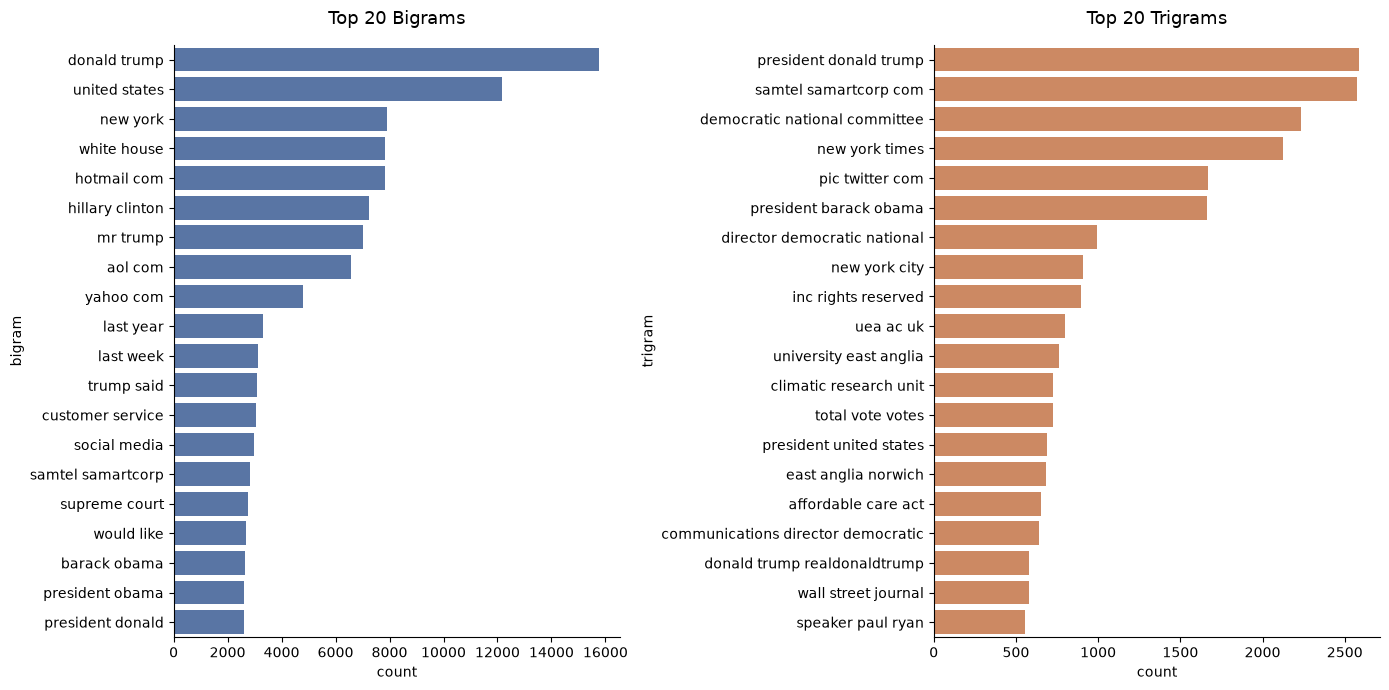

In [29]:
# Visualize top bigrams & trigrams
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.barplot(data=top_bigrams, x='count', y='bigram', color='#4C72B0', ax=axes[0])
axes[0].set_title(f'Top {top_n} Bigrams', fontsize=13, pad=15)
axes[0].spines[['top', 'right']].set_visible(False)

sns.barplot(data=top_trigrams, x='count', y='trigram', color='#DD8452', ax=axes[1])
axes[1].set_title(f'Top {top_n} Trigrams', fontsize=13, pad=15)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
# Compare top n-grams by label / category
def top_ngrams_by_group(df, ngram_col, group_col, group_val, n=15):
    grams = [g for grams in df.loc[df[group_col] == group_val, ngram_col] for g in grams]
    return Counter(grams).most_common(n)

for label_val in sorted(df['label'].unique()):
    print(f"--- label={label_val} (top bigrams) ---")
    print(top_ngrams_by_group(df, 'bigrams', 'label', label_val))
    print()

for cat in df['category'].unique():
    print(f"--- category={cat} (top bigrams) ---")
    print(top_ngrams_by_group(df, 'bigrams', 'category', cat))
    print()

--- label=0 (top bigrams) ---
[(('donald', 'trump'), 9564), (('united', 'states'), 8844), (('mr', 'trump'), 6647), (('new', 'york'), 6145), (('white', 'house'), 5550), (('hillary', 'clinton'), 3171), (('samtel', 'samartcorp'), 2832), (('last', 'year'), 2745), (('last', 'week'), 2610), (('trump', 'said'), 2592), (('samartcorp', 'com'), 2584), (('national', 'committee'), 2392), (('social', 'media'), 2355), (('may', 'pm'), 2336), (('president', 'donald'), 2335)]

--- label=1 (top bigrams) ---
[(('hotmail', 'com'), 7314), (('aol', 'com'), 6438), (('donald', 'trump'), 6184), (('yahoo', 'com'), 4343), (('hillary', 'clinton'), 4050), (('united', 'states'), 3317), (('white', 'house'), 2292), (('new', 'york'), 1747), (('twitter', 'com'), 1745), (('pic', 'twitter'), 1646), (('paypal', 'account'), 1592), (('rights', 'reserved'), 1523), (('president', 'obama'), 1352), (('army', 'mil'), 1315), (('privacy', 'policy'), 1172)]

--- category=fake_news (top bigrams) ---
[(('donald', 'trump'), 11743), ((

In [32]:
# Fit TF-IDF vectorizer on raw text
# TfidfVectorizer handles tokenization/stopwords internally, so it can run directly on df['text']
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    token_pattern=r'[a-zA-Z]{2,}',   # letters only, min length 2
    max_df=0.9,                       # drop terms that appear in >90% of docs
    min_df=5                          # drop terms that appear in fewer than 5 docs
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['text'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (56597, 45871)


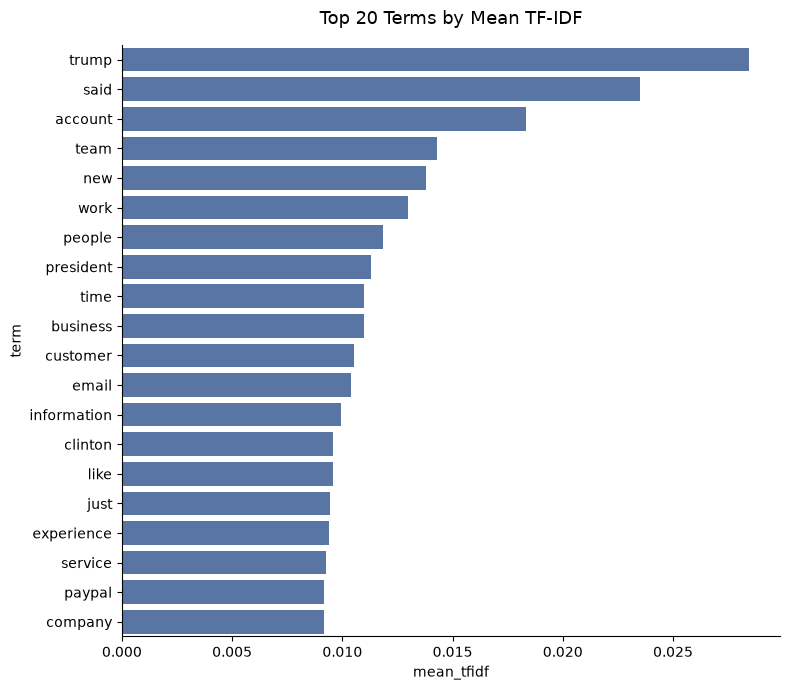

In [ ]:
# Top terms overall by mean TF-IDF score
mean_tfidf = tfidf_matrix.mean(axis=0).A1
top_n = 20

tfidf_scores = pd.DataFrame({'term': feature_names, 'mean_tfidf': mean_tfidf})
top_terms = tfidf_scores.sort_values('mean_tfidf', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=top_terms, x='mean_tfidf', y='term', color='#4C72B0', ax=ax)
ax.set_title(f'Top {top_n} Terms by Mean TF-IDF', fontsize=13, pad=15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Top TF-IDF terms per label
def top_terms_by_group(matrix, group_mask, feature_names, n=15):
    group_matrix = matrix[group_mask.values]
    mean_scores = group_matrix.mean(axis=0).A1
    scores_df = pd.DataFrame({'term': feature_names, 'mean_tfidf': mean_scores})
    return scores_df.sort_values('mean_tfidf', ascending=False).head(n)

for label_val in sorted(df['label'].unique()):
    print(f"--- label={label_val} ---")
    print(top_terms_by_group(tfidf_matrix, df['label'] == label_val, feature_names))
    print()

--- label=0 ---
              term  mean_tfidf
35369         said    0.027825
41995        trump    0.022442
40429         team    0.018090
45182         work    0.016254
27373          new    0.014489
5434      business    0.012732
14230   experience    0.011903
7832       company    0.011482
23909      looking    0.011199
41148         time    0.011152
35409        sales    0.010973
31411    president    0.010696
29911       people    0.010611
26604           mr    0.010393
10904  development    0.010197

--- label=1 ---
              term  mean_tfidf
298        account    0.054399
41995        trump    0.042642
29711       paypal    0.030293
12568         ebay    0.024812
20423  information    0.020072
12979        email    0.019899
7184         click    0.017888
7238       clinton    0.017766
3216          bank    0.015749
24360         mail    0.015243
29911       people    0.014819
36159     security    0.014167
28431       online    0.014004
43116       update    0.013874
18749 

In [35]:
# Top TF-IDF terms per category
for cat in df['category'].unique():
    print(f"--- category={cat} ---")
    print(top_terms_by_group(tfidf_matrix, df['category'] == cat, feature_names))
    print()

--- category=fake_news ---
             term  mean_tfidf
41995       trump    0.068563
35369        said    0.060205
31411   president    0.028596
7238      clinton    0.024488
29911      people    0.021704
26604          mr    0.020552
38712       state    0.018663
28049       obama    0.018044
19201       house    0.017088
11892      donald    0.016969
17231  government    0.015848
34013  republican    0.015701
38724      states    0.015333
12852    election    0.014786
27373         new    0.014726

--- category=job_scams ---
              term  mean_tfidf
40429         team    0.046057
45182         work    0.036613
14230   experience    0.032767
35409        sales    0.029508
23909      looking    0.028307
7832       company    0.027752
5434      business    0.027220
9602      customer    0.027046
10904  development    0.026950
31659      product    0.025224
10736       design    0.024773
24737    marketing    0.024751
24511   management    0.023686
7194        client    0.020613


In [36]:
# Inspect the highest-scoring terms for a single document (sanity check)
def top_terms_for_doc(matrix, doc_idx, feature_names, n=10):
    row = matrix[doc_idx].toarray().flatten()
    top_idx = row.argsort()[::-1][:n]
    return [(feature_names[i], round(row[i], 4)) for i in top_idx if row[i] > 0]

sample_idx = df.sample(1, random_state=42).index[0]
print(df.loc[sample_idx, ['category', 'label']])
print(top_terms_for_doc(tfidf_matrix, sample_idx, feature_names))

category    job_scams
label               0
Name: 26359, dtype: object
[('lost', np.float64(0.3064)), ('magical', np.float64(0.2146)), ('experience', np.float64(0.1792)), ('stack', np.float64(0.1752)), ('books', np.float64(0.156)), ('commerce', np.float64(0.1542)), ('experiences', np.float64(0.1501)), ('startup', np.float64(0.1484)), ('hackney', np.float64(0.1408)), ('end', np.float64(0.1392))]


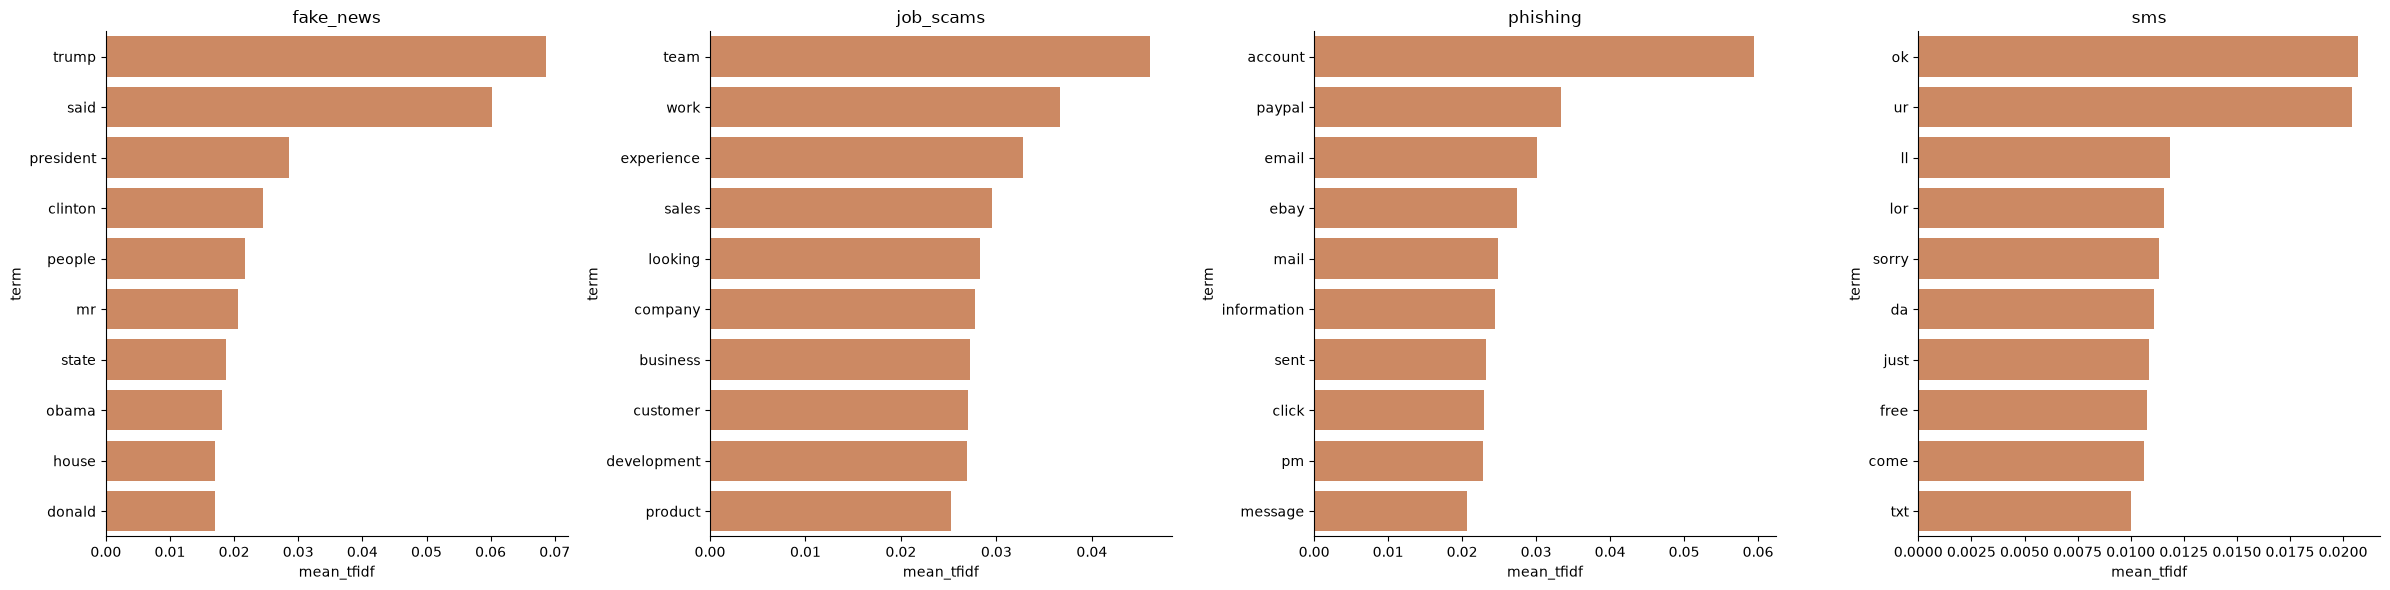

In [37]:
# Visualize TF-IDF top terms per category as subplots
categories = df['category'].unique()
fig, axes = plt.subplots(1, len(categories), figsize=(6 * len(categories), 6))

for ax, cat in zip(axes, categories):
    top_cat_terms = top_terms_by_group(tfidf_matrix, df['category'] == cat, feature_names, n=10)
    sns.barplot(data=top_cat_terms, x='mean_tfidf', y='term', color='#DD8452', ax=ax)
    ax.set_title(cat, fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Define regex patterns for URL / special-character detection
url_pattern = re.compile(r'https?://\S+|www\.\S+')
email_pattern = re.compile(r'\b[\w.-]+@[\w.-]+\.\w+\b')
phone_pattern = re.compile(r'\b\d{2,4}[-.\s]?\d{3,4}[-.\s]?\d{4}\b')
special_char_pattern = re.compile(r'[^a-zA-Z0-9\s]')   # anything that's not alphanumeric/whitespace
digit_pattern = re.compile(r'\d')

# Compute counts and ratios per row
df['url_count'] = df['text'].apply(lambda t: len(url_pattern.findall(t)))
df['email_count'] = df['text'].apply(lambda t: len(email_pattern.findall(t)))
df['phone_count'] = df['text'].apply(lambda t: len(phone_pattern.findall(t)))
df['special_char_count'] = df['text'].apply(lambda t: len(special_char_pattern.findall(t)))
df['digit_count'] = df['text'].apply(lambda t: len(digit_pattern.findall(t)))

# ratios normalized by character length (avoid div-by-zero with the existing char_count column)
df['special_char_ratio'] = df['special_char_count'] / df['char_count']
df['digit_ratio'] = df['digit_count'] / df['char_count']
df['uppercase_ratio'] = df['text'].apply(lambda t: sum(1 for c in t if c.isupper()) / len(t) if len(t) > 0 else 0)

# boolean flags: does the text contain at least one URL/email/phone?
df['has_url'] = df['url_count'] > 0
df['has_email'] = df['email_count'] > 0
df['has_phone'] = df['phone_count'] > 0

df[['url_count', 'email_count', 'phone_count', 'special_char_ratio', 'digit_ratio', 'uppercase_ratio']].describe()

,url_count,email_count,phone_count,special_char_ratio,digit_ratio,uppercase_ratio
count,56597.000000,56597.000000,56597.000000,56597.000000,56597.000000,56597.000000
mean,0.076806,1.101436,0.181635,0.038381,0.014045,0.047935
std,0.475923,185.645862,4.042596,0.036027,0.031813,0.053784
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.020774,0.000000,0.026145
50%,0.000000,0.000000,0.000000,0.027369,0.004267,0.035497
75%,0.000000,0.000000,0.000000,0.039548,0.012346,0.051680
max,31.000000,44150.000000,790.000000,1.000000,1.000000,1.000000


     feature  ratio (%)
0    has_url   5.178720
1  has_email  10.295599
2  has_phone   7.643515


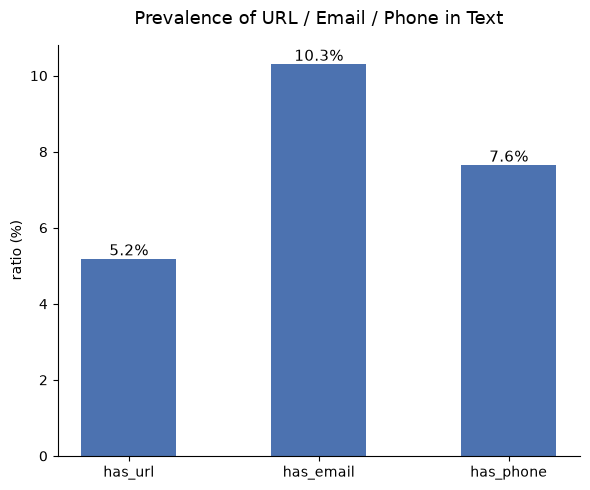

In [ ]:
# Overall prevalence: what % of texts contain a URL / email / phone number?
presence_summary = pd.DataFrame({
    'feature': ['has_url', 'has_email', 'has_phone'],
    'ratio (%)': [
        df['has_url'].mean() * 100,
        df['has_email'].mean() * 100,
        df['has_phone'].mean() * 100,
    ]
})
print(presence_summary)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(presence_summary['feature'], presence_summary['ratio (%)'], color='#4C72B0', width=0.5)

for bar, val in zip(bars, presence_summary['ratio (%)']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_title('Prevalence of URL / Email / Phone in Text', fontsize=13, pad=15)
ax.set_ylabel('ratio (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

             has_url  has_email  has_phone
category                                  
fake_news   5.709816   0.327532   0.229761
job_scams   0.034977   0.006995   0.090941
phishing   10.273704  37.578575  23.160031
sms         2.874962   0.304229  11.089139


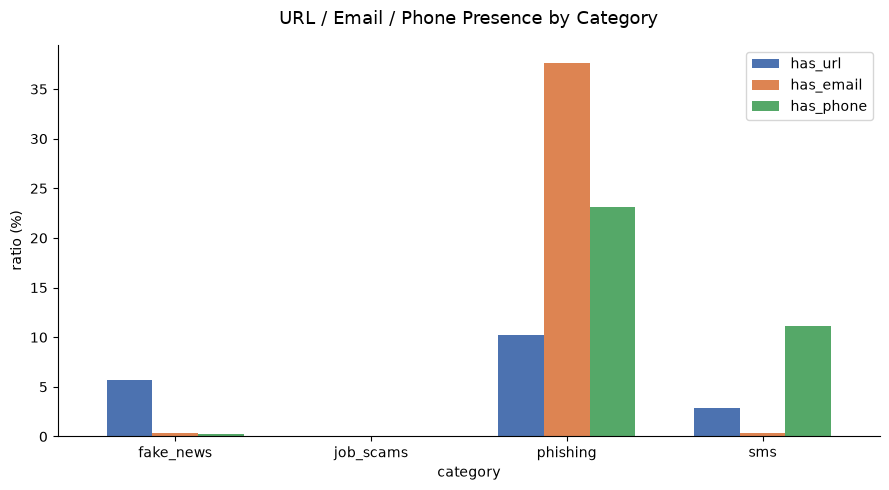

In [40]:
# Compare prevalence by category (URLs/emails are common phishing signals)
presence_by_cat = df.groupby('category')[['has_url', 'has_email', 'has_phone']].mean() * 100
print(presence_by_cat)

fig, ax = plt.subplots(figsize=(9, 5))
presence_by_cat.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'], width=0.7)
ax.set_title('URL / Email / Phone Presence by Category', fontsize=13, pad=15)
ax.set_ylabel('ratio (%)')
ax.set_xlabel('category')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

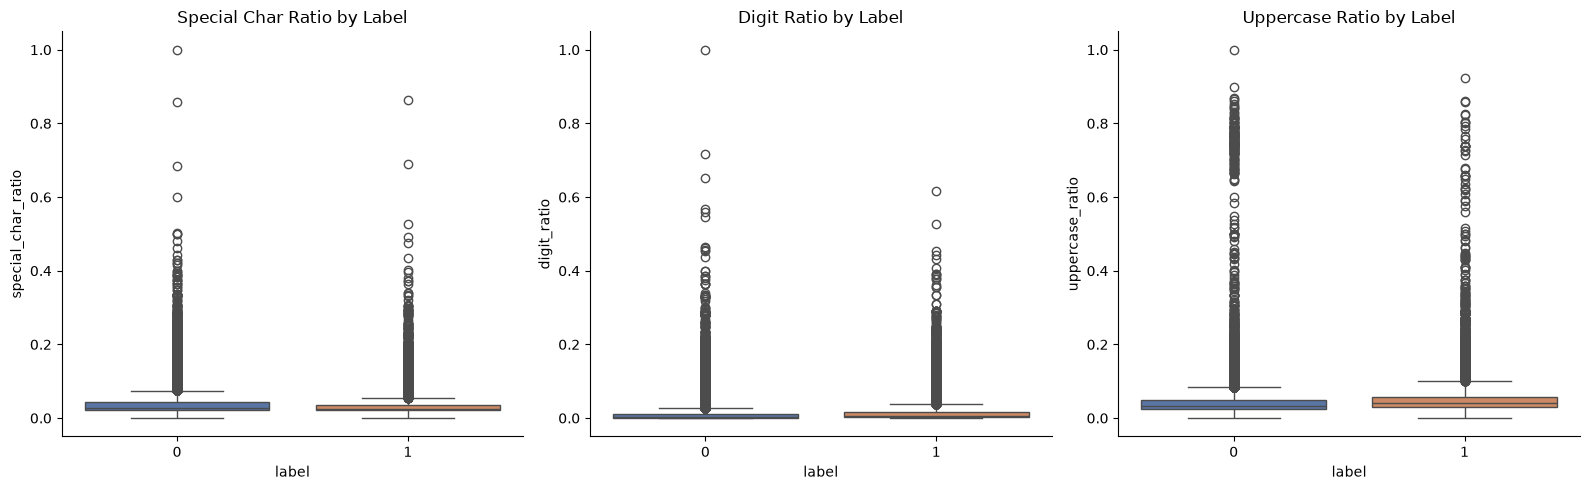

In [ ]:
# Distribution of special-character / digit / uppercase ratios by label
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='label', y='special_char_ratio', ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Special Char Ratio by Label')
axes[0].spines[['top', 'right']].set_visible(False)

sns.boxplot(data=df, x='label', y='digit_ratio', ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Digit Ratio by Label')
axes[1].spines[['top', 'right']].set_visible(False)

sns.boxplot(data=df, x='label', y='uppercase_ratio', ax=axes[2], palette=['#4C72B0', '#DD8452'])
axes[2].set_title('Uppercase Ratio by Label')
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [42]:
# Build dictionary & corpus from tokenized text
texts = df['tokens'].tolist()

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)   # drop rare & overly common terms

corpus = [dictionary.doc2bow(text) for text in texts]

print(f"Number of unique tokens: {len(dictionary)}")
print(f"Number of documents: {len(corpus)}")

Number of unique tokens: 46031
Number of documents: 56597


In [43]:
# Train LDA model
num_topics = 5

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

# print top words per topic
for topic_id, words in lda_model.print_topics(num_words=10):
    print(f"Topic {topic_id}: {words}")
    print()

Topic 0: 0.015*"said" + 0.006*"would" + 0.005*"mr" + 0.005*"government" + 0.004*"states" + 0.004*"people" + 0.004*"united" + 0.004*"year" + 0.004*"also" + 0.004*"state"

Topic 1: 0.022*"account" + 0.016*"please" + 0.014*"com" + 0.013*"email" + 0.012*"information" + 0.010*"ebay" + 0.009*"mail" + 0.009*"paypal" + 0.008*"may" + 0.007*"message"

Topic 2: 0.009*"team" + 0.009*"work" + 0.007*"company" + 0.007*"business" + 0.006*"new" + 0.005*"experience" + 0.005*"sales" + 0.004*"development" + 0.004*"management" + 0.004*"looking"

Topic 3: 0.019*"trump" + 0.006*"pm" + 0.006*"democratic" + 0.006*"party" + 0.006*"may" + 0.006*"donald" + 0.005*"national" + 0.005*"said" + 0.005*"would" + 0.005*"dnc"

Topic 4: 0.020*"com" + 0.005*"hotmail" + 0.005*"one" + 0.005*"get" + 0.005*"aol" + 0.004*"would" + 0.004*"net" + 0.004*"yahoo" + 0.004*"time" + 0.004*"like"



In [44]:
# Evaluate topic quality with coherence score
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f"Coherence Score (c_v): {coherence_score:.4f}")

Coherence Score (c_v): 0.4924


num_topics=2, coherence=0.4326
num_topics=3, coherence=0.5824
num_topics=4, coherence=0.4878
num_topics=5, coherence=0.4982
num_topics=6, coherence=0.4889
num_topics=7, coherence=0.5334
num_topics=8, coherence=0.5347
num_topics=9, coherence=0.5124
num_topics=10, coherence=0.5263


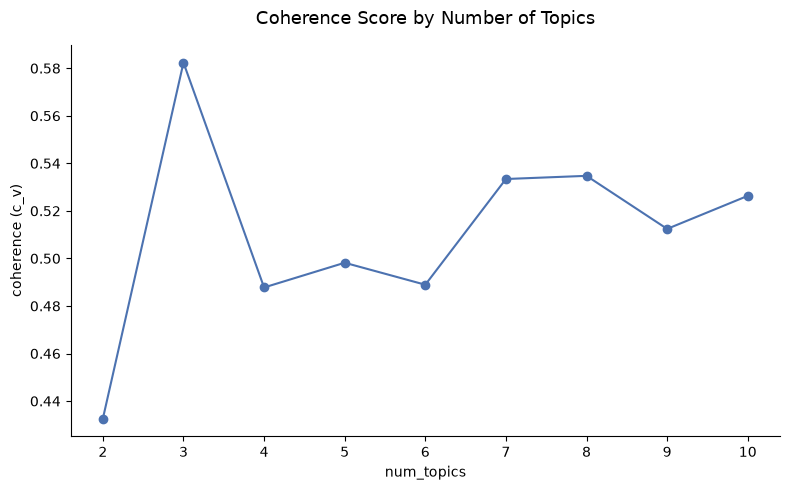

In [45]:
# Compare coherence across different numbers of topics
coherence_scores = []
topic_range = range(2, 11)

for k in topic_range:
    model_k = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k, random_state=42, passes=5)
    cm = CoherenceModel(model=model_k, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_scores.append(cm.get_coherence())
    print(f"num_topics={k}, coherence={coherence_scores[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(topic_range), coherence_scores, marker='o', color='#4C72B0')
ax.set_title('Coherence Score by Number of Topics', fontsize=13, pad=15)
ax.set_xlabel('num_topics')
ax.set_ylabel('coherence (c_v)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [46]:
# Assign dominant topic to each document
def get_dominant_topic(bow, model):
    topic_probs = model.get_document_topics(bow)
    return max(topic_probs, key=lambda x: x[1]) if topic_probs else (None, None)

dominant = [get_dominant_topic(bow, lda_model) for bow in corpus]
df['dominant_topic'] = [d[0] for d in dominant]
df['topic_prob'] = [d[1] for d in dominant]

df[['category', 'label', 'dominant_topic', 'topic_prob']].head(10)

,category,label,dominant_topic,topic_prob
0,fake_news,1,0,0.749122
1,fake_news,0,0,0.599140
2,fake_news,0,0,0.933458
3,fake_news,0,0,0.990774
4,fake_news,0,0,0.862580
5,fake_news,1,3,0.548024
6,fake_news,1,3,0.476994
7,fake_news,0,0,0.899928
8,fake_news,0,3,0.571662
9,fake_news,0,0,0.661612


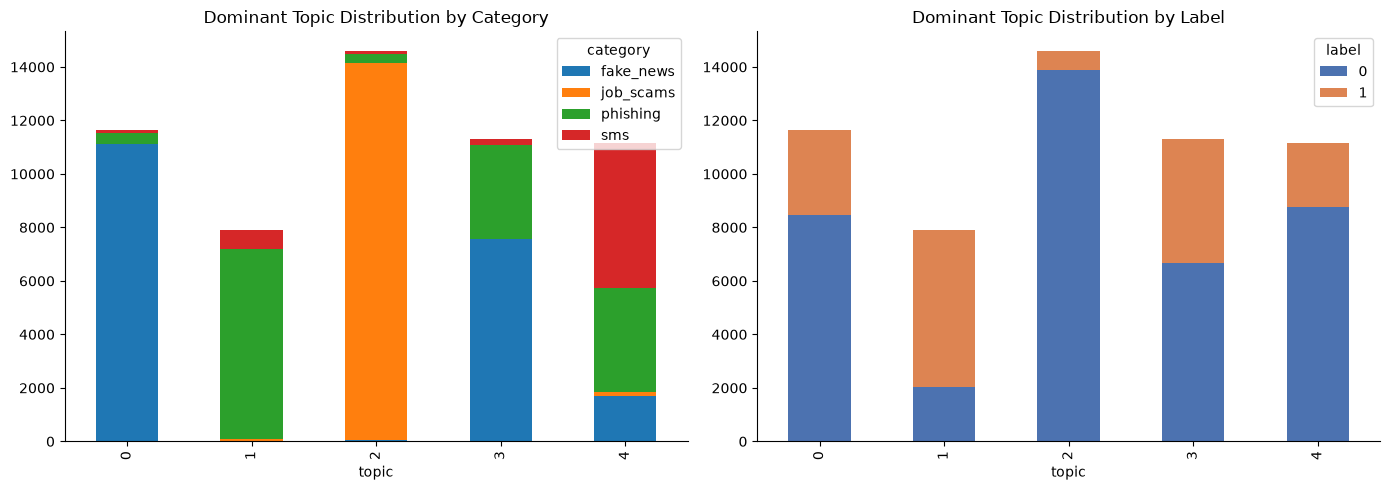

In [47]:
# Topic distribution by category / label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.crosstab(df['dominant_topic'], df['category']).plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Dominant Topic Distribution by Category', fontsize=12)
axes[0].set_xlabel('topic')
axes[0].spines[['top', 'right']].set_visible(False)

pd.crosstab(df['dominant_topic'], df['label']).plot(kind='bar', stacked=True, ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Dominant Topic Distribution by Label', fontsize=12)
axes[1].set_xlabel('topic')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [48]:
# Interactive visualization with pyLDAvis
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.120465 -0.059682       1        1  31.765505
3      0.164222  0.044568       2        1  24.610724
4      0.091356  0.069371       3        1  17.873166
2     -0.144037 -0.216608       4        1  17.514058
1     -0.232005  0.162351       5        1   8.236547, topic_info=          Term          Freq         Total Category  logprob  loglift
227      trump  53743.000000  53743.000000  Default  30.0000  30.0000
817        com  58434.000000  58434.000000  Default  29.0000  29.0000
5685   account  21028.000000  21028.000000  Default  28.0000  28.0000
198       said  69233.000000  69233.000000  Default  27.0000  27.0000
1408    please  18607.000000  18607.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
6214  customer   3783.527266  11036.212731   Topic5  -5.4797   1.4261
3135        pm   4597.179778  22368.402387   Topic5  -5.2849   0.9144
1542        us   4549.369551  23758.892434   Topic5  -5.2953   0.8436
1106      call   3352.005537  13600.826681   Topic5  -5.6008   1.0960
1367      help   3369.512579  15093.102233   Topic5  -5.5955   0.9971

[404 rows x 6 columns], token_table=       Topic      Freq    Term
term                          
14691      1  0.000491      ac
14691      3  0.990637      ac
14691      4  0.008841      ac
240        1  0.170887  access
240        2  0.047241  access
...      ...       ...     ...
577        3  0.187301   years
577        4  0.176160   years
43652      1  0.001347   zdnet
43652      3  0.996591   zdnet
19856      1  0.999149    zika

[1024 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 4, 5, 3, 2])

In [49]:
# Build word co-occurrence pairs from tokenized text
# Co-occurrence = two words appearing in the same document (row)
# Limit to top-K frequent words first to keep the graph readable and tractable
top_k = 50
top_words_set = {w for w, _ in word_freq.most_common(top_k)}   # reuses word_freq from earlier EDA

def get_cooccurrence_pairs(tokens, vocab):
    unique_tokens = sorted(set(t for t in tokens if t in vocab))   # dedupe within a doc, sort for stable pairs
    return list(combinations(unique_tokens, 2))

cooc_counter = Counter()
for tokens in df['tokens']:
    pairs = get_cooccurrence_pairs(tokens, top_words_set)
    cooc_counter.update(pairs)

print(f"Number of unique word pairs: {len(cooc_counter)}")
cooc_counter.most_common(10)

Number of unique word pairs: 1225


[(('said', 'would'), 10403),
 (('one', 'said'), 9455),
 (('one', 'would'), 9411),
 (('president', 'said'), 9123),
 (('also', 'said'), 9058),
 (('also', 'would'), 8963),
 (('also', 'one'), 8907),
 (('people', 'said'), 8711),
 (('one', 'people'), 8664),
 (('donald', 'trump'), 8635)]

In [50]:
# Build the co-occurrence graph
min_edge_weight = 20   # drop weak/noisy edges

G = nx.Graph()

for word in top_words_set:
    G.add_node(word, freq=word_freq[word])

for (w1, w2), weight in cooc_counter.items():
    if weight >= min_edge_weight:
        G.add_edge(w1, w2, weight=weight)

# drop isolated nodes (words with no edge above the threshold)
G.remove_nodes_from(list(nx.isolates(G)))

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Nodes: 50, Edges: 1225


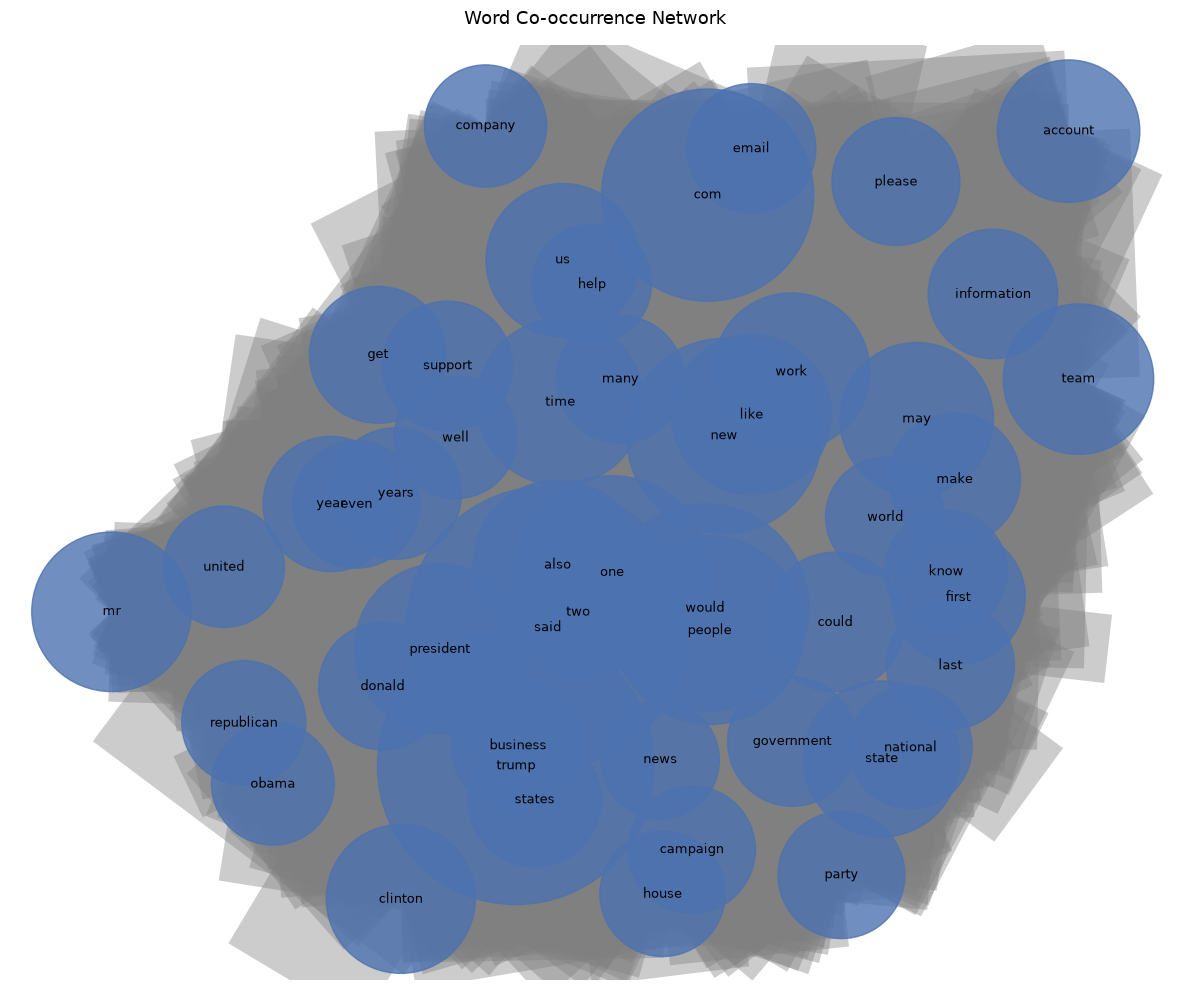

In [51]:
# Visualize the co-occurrence network
fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(G, k=0.5, seed=42)

node_sizes = [G.nodes[n]['freq'] * 0.5 for n in G.nodes]
edge_weights = [G.edges[e]['weight'] * 0.05 for e in G.edges]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#4C72B0', alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color='gray', alpha=0.4, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)

ax.set_title('Word Co-occurrence Network', fontsize=13, pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

In [52]:
# Identify central/hub words with graph metrics
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

centrality_df = pd.DataFrame({
    'word': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness_centrality': [betweenness_centrality[w] for w in degree_centrality.keys()]
}).sort_values('degree_centrality', ascending=False)

centrality_df.head(15)

,word,degree_centrality,betweenness_centrality
0,world,1.0,0.0
37,donald,1.0,0.0
27,two,1.0,0.0
28,last,1.0,0.0
29,national,1.0,0.0
30,years,1.0,0.0
31,news,1.0,0.0
32,state,1.0,0.0
33,please,1.0,0.0
34,mr,1.0,0.0


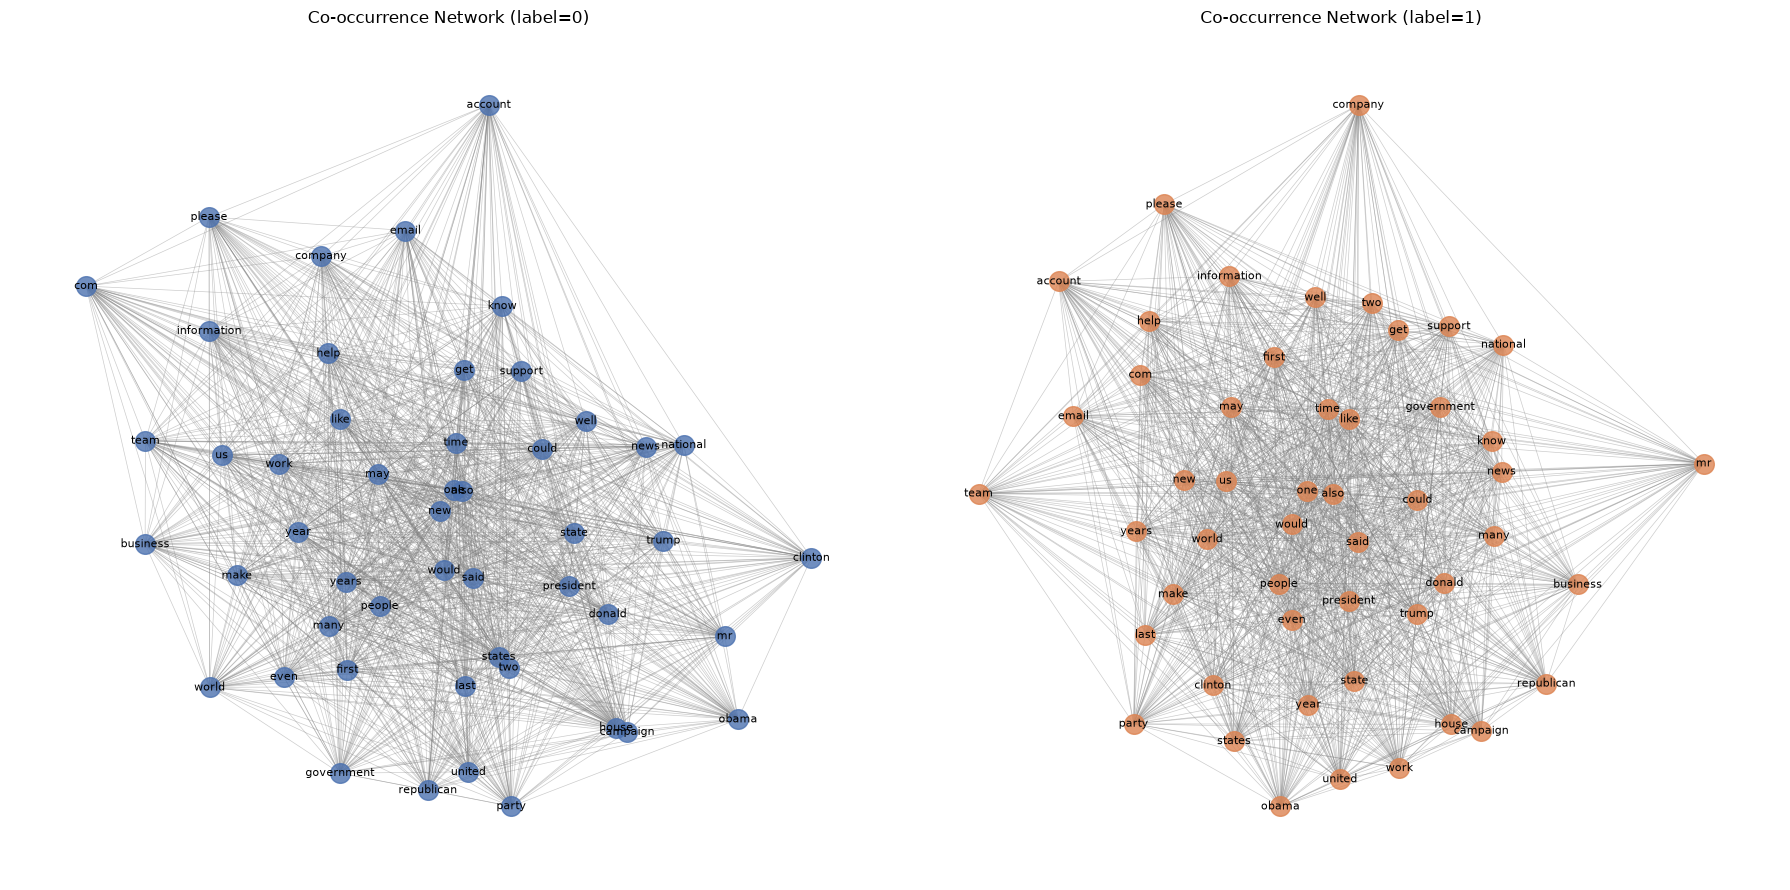

In [53]:
# Compare co-occurrence networks by label (e.g. fraud vs. non-fraud)
def build_cooc_graph(sub_df, vocab, min_weight=10):
    cooc = Counter()
    for tokens in sub_df['tokens']:
        cooc.update(get_cooccurrence_pairs(tokens, vocab))

    g = nx.Graph()
    for (w1, w2), weight in cooc.items():
        if weight >= min_weight:
            g.add_edge(w1, w2, weight=weight)
    return g

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, label_val, color in zip(axes, sorted(df['label'].unique()), ['#4C72B0', '#DD8452']):
    sub_df = df[df['label'] == label_val]
    g = build_cooc_graph(sub_df, top_words_set, min_weight=10)
    pos = nx.spring_layout(g, k=0.5, seed=42)

    nx.draw_networkx_nodes(g, pos, node_size=200, node_color=color, alpha=0.8, ax=ax)
    nx.draw_networkx_edges(g, pos, width=0.5, edge_color='gray', alpha=0.4, ax=ax)
    nx.draw_networkx_labels(g, pos, font_size=8, ax=ax)

    ax.set_title(f'Co-occurrence Network (label={label_val})', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()